 Cell 1 — Styled Banner 

# 🧠 MindBridge — Problem Understanding
### Step 1: Defining the Problem Space

> **Goal:** Classify mental health status from social media text using Natural Language Processing and Machine Learning.

---

| Property | Detail |
|----------|--------|
| **Task Type** | Multi-class Text Classification |
| **Input** | Raw social media text (Reddit posts, tweets) |
| **Output** | One of 7 mental health status labels |
| **Approach** | NLP Preprocessing → TF-IDF → Classical ML Models |
| **Dataset** | ~53,000 labeled samples (Kaggle) |

🐍 Cell 2 — Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("darkgrid")

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [6]:
df = pd.read_csv('/Users/vaibhav2040/Desktop/MIND_BRIDGE/Combined Data.csv')

In [10]:
df = pd.read_csv('/Users/vaibhav2040/Desktop/MIND_BRIDGE/Combined Data.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = ['statement', 'status']

print("=" * 55)
print("         📊 MINDBRIDGE — DATASET OVERVIEW")
print("=" * 55)
print(f"  Total Samples     : {len(df):,}")
print(f"  Total Features    : {df.shape[1]}")
print(f"  Missing Values    : {df.isnull().sum().sum()}")
print(f"  Duplicate Rows    : {df.duplicated().sum():,}")
print("=" * 55)
print(f"\n🏷️  Output Classes ({df['status'].nunique()} total):\n")
for i, cls in enumerate(sorted(df['status'].unique()), 1):
    count = df['status'].value_counts()[cls]
    pct = count / len(df) * 100
    print(f"   {i}. {cls:<25} → {count:>6,} samples  ({pct:.1f}%)")
print("=" * 55)

         📊 MINDBRIDGE — DATASET OVERVIEW
  Total Samples     : 53,043
  Total Features    : 2
  Missing Values    : 362
  Duplicate Rows    : 1,944

🏷️  Output Classes (7 total):

   1. Anxiety                   →  3,888 samples  (7.3%)
   2. Bipolar                   →  2,877 samples  (5.4%)
   3. Depression                → 15,404 samples  (29.0%)
   4. Normal                    → 16,351 samples  (30.8%)
   5. Personality disorder      →  1,201 samples  (2.3%)
   6. Stress                    →  2,669 samples  (5.0%)
   7. Suicidal                  → 10,653 samples  (20.1%)


In [11]:
html = """
<div style="
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    border-radius: 16px;
    padding: 30px 40px;
    font-family: 'Segoe UI', sans-serif;
    color: white;
    margin: 10px 0;
    border-left: 6px solid #6C63FF;
">
    <h2 style="color:#6C63FF; margin-bottom:6px;">🧠 MindBridge — Problem Statement</h2>
    <p style="color:#aaa; font-size:13px; margin-bottom:20px;">NLP Text Classification Project</p>
    <table style="width:100%; border-collapse:collapse;">
        <tr>
            <td style="padding:10px 16px; background:rgba(108,99,255,0.15); border-radius:8px; width:50%; vertical-align:top;">
                <b style="color:#48CAE4;">🎯 Objective</b><br/>
                <span style="font-size:14px;">Automatically classify social media text into one of 7 mental health status categories using NLP and Machine Learning.</span>
            </td>
            <td style="width:2%;"></td>
            <td style="padding:10px 16px; background:rgba(72,202,228,0.1); border-radius:8px; width:48%; vertical-align:top;">
                <b style="color:#48CAE4;">💡 Motivation</b><br/>
                <span style="font-size:14px;">Mental health crises often manifest in language before clinical detection. NLP enables scalable early-warning systems.</span>
            </td>
        </tr>
    </table>
    <br/>
    <table style="width:100%; border-collapse:collapse;">
        <tr>
            <td style="padding:10px 16px; background:rgba(255,255,255,0.05); border-radius:8px; width:23%; text-align:center;">
                <div style="font-size:28px;">📝</div>
                <div style="color:#6C63FF; font-weight:bold;">Input</div>
                <div style="font-size:13px; color:#ccc;">Raw social media text</div>
            </td>
            <td style="text-align:center; font-size:24px; color:#6C63FF;">→</td>
            <td style="padding:10px 16px; background:rgba(255,255,255,0.05); border-radius:8px; width:23%; text-align:center;">
                <div style="font-size:28px;">🔧</div>
                <div style="color:#6C63FF; font-weight:bold;">Process</div>
                <div style="font-size:13px; color:#ccc;">NLP + TF-IDF + ML</div>
            </td>
            <td style="text-align:center; font-size:24px; color:#6C63FF;">→</td>
            <td style="padding:10px 16px; background:rgba(255,255,255,0.05); border-radius:8px; width:23%; text-align:center;">
                <div style="font-size:28px;">🏷️</div>
                <div style="color:#6C63FF; font-weight:bold;">Output</div>
                <div style="font-size:13px; color:#ccc;">7 mental health labels</div>
            </td>
            <td style="text-align:center; font-size:24px; color:#6C63FF;">→</td>
            <td style="padding:10px 16px; background:rgba(255,255,255,0.05); border-radius:8px; width:23%; text-align:center;">
                <div style="font-size:28px;">💊</div>
                <div style="color:#6C63FF; font-weight:bold;">Impact</div>
                <div style="font-size:13px; color:#ccc;">Early mental health detection</div>
            </td>
        </tr>
    </table>
    <br/>
    <p style="color:#aaa; font-size:12px; margin:0;">
        📦 Dataset: ~53,000 samples &nbsp;|&nbsp;
        🏷️ Classes: 7 &nbsp;|&nbsp;
        🔬 Models: LR, NB, RF, SVM &nbsp;|&nbsp;
        📐 Metric: F1 Score (Macro)
    </p>
</div>
"""
display(HTML(html))

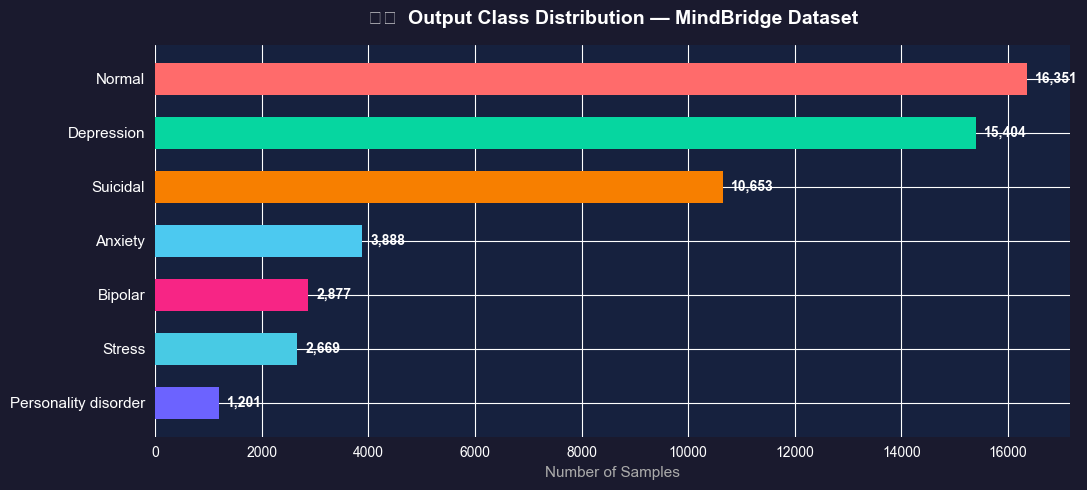

✅ Plot saved to results/plots/


In [14]:
class_counts = df['status'].value_counts().sort_values(ascending=True)
colors = ['#6C63FF','#48CAE4','#f72585','#4cc9f0','#f77f00','#06d6a0','#ff6b6b']

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

bars = ax.barh(class_counts.index, class_counts.values,
               color=colors, height=0.6, edgecolor='none')

for bar, val in zip(bars, class_counts.values):
    ax.text(val + 150, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='left',
            color='white', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Samples', color='#aaa', fontsize=11)
ax.set_title('🏷️  Output Class Distribution — MindBridge Dataset',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.spines[['top','right','bottom','left']].set_visible(False)
for label in ax.get_yticklabels():
    label.set_color('white')
    label.set_fontsize(11)

plt.tight_layout()
plt.savefig('/Users/vaibhav2040/Desktop/MIND_BRIDGE/results/plots/00_class_distribution_preview.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ Plot saved to results/plots/")

## ✅ Step 1 Complete — Key Takeaways

| Finding | Detail |
|---------|--------|
| **Dataset Size** | ~53,000 samples — sufficient for classical ML |
| **Classes** | 7 distinct mental health states confirmed |
| **Task** | Multi-class NLP classification |
| **Key Challenge** | Class imbalance — will handle in preprocessing |
| **Success Metric** | Macro F1 Score (accounts for imbalance) |

### 📌 Next Step → `02_Preprocessing.ipynb`
- Clean text (lowercase, punctuation, stopwords, lemmatization)
- Convert text to numbers via TF-IDF